### 결정트리
- 예측원리 : 루트노드부터 시작 -> 각 노드의 질문에 따라 가지를 타고 내려가 -> 최종 리프노드에 도달하여 예측값을 얻는 과정
- 클래스 확률 추청 : 특정 데이터가 각 클래스에 속할 확률을 어떻게 계산하는지 설명
- 규제 하이퍼 파라미터 : 훈련데이터에 너무 과하게 맞춰지는 과대적합(overfitting / 과소적합은 학습이 안된것)을 막기위한 파라미터들을 조정
    - max_depth	나무의 깊이를 제한 (질문 몇 번까지만 하자!)
    - min_samples_split	너무 작은 그룹은 더 이상 나누지 말자
    - min_samples_leaf	리프노드에 최소 몇 개의 데이터가 있어야 한다
- 회귀에도 사용 가능 : 특정 수치를 예측하는 회귀 문제에 적용 가능 - 불순도(Gini) 대신 MSE 사용
    - 분류(classification): 탈퇴 or 유지 (0 or 1)
    - 회귀(regression): 가격, 점수, 온도 같은 수치 예측
- 불안정성 : 작은 변화에도 민감하게 반응해서 트리구조가 완전히 달라질 수 있음 --> 랜덤포레스트 등장의 배경이 됨
- 노드 분할의 기준 : 지니계수 (Gini impurity) 
    - 한 그룹(노드)에 얼마나 다른 데이터들이 섞여 있는가?를 나타내는 지표
    - 0 : 완전 순수 : 한 그룹에 하나의 클래스 (ex. 상자에 파란공만 있는것)
    - 질문을 통해서 데이터를 나눌 때 다음 그룹들의 지니불순도가 최대한 낮아지도록 하는 질문 (지표)
- 결정트리 장점 : 스케일링을 안해줘도 됨. 영향을 받지 않음.

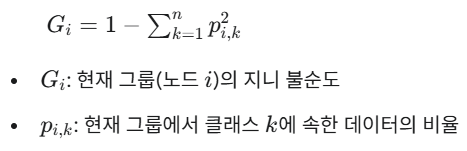

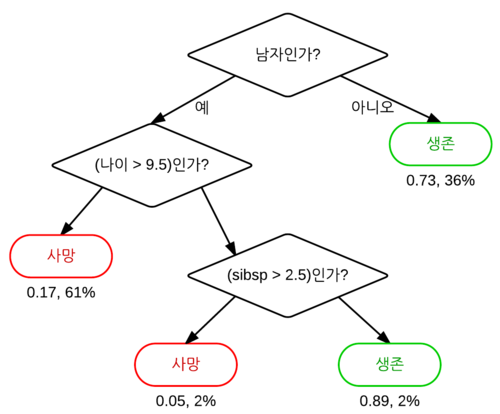

In [43]:
# 노드의 50개의 데이터가 붓꽃 A 40개 B 10개
# A의 비율 (Pa) = 40 / 50 = 0.8
# B의 비율 (Pb) = 10 / 50 = 0.2
# 지니불순도 1 - (0.8^2 + 0.2^2) = 0.32

# 결정트리가 사용하는 알고리즘 : CART 알고리즘
# 1. 모든 가능한 질문 생성 : 하나의 특성 (ex.꽃잎의 길이) 가능한 모든 임계값 (ex 2.25cm 1cm) 조합해서 질문ㄴ
# 2. 불순도 감소량 계산 : 각 질문으로 데이터를 두개로 나눌 때 분할전 부모노드의 불순도 - 두 자식의 불순도 가중평균을 구함. 이 값이 클수록 더 좋은 질문.


In [44]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
iris = load_iris(as_frame=True)   #as_frame=True 이거 안하면 numpy
X = iris.data.iloc [:, 2:]  # == 같음 == iris.data.iloc [:, [2,3]]
y = iris.target

tree = DecisionTreeClassifier()
tree.fit(X,y)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


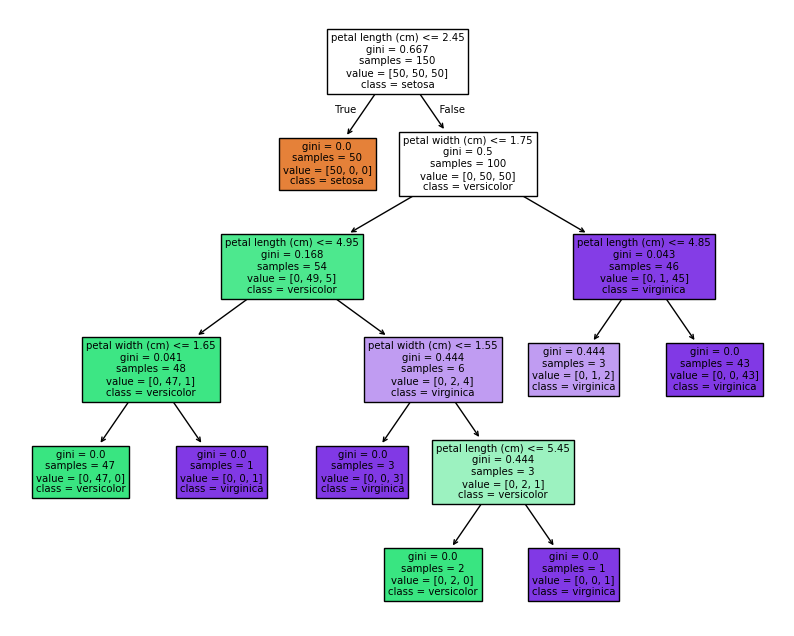

In [45]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(10,8))
plot_tree(tree, feature_names=X.columns, class_names=iris.target_names, filled=True);

In [46]:
# tree 모델은 학습 후 가장 중요한 피쳐들의 정보를 출력
tree.feature_importances_, tree.feature_names_in_
# 출력 값 : 
# (array([0.06492158, 0.93507842]) ==> 두번째 값이 더 중요 하다고 모델은 판단.
# array(['petal length (cm)', 'petal width (cm)'], dtype=object)) => 두번째 값은 petal width에 대한것임

(array([0.57167834, 0.42832166]),
 array(['petal length (cm)', 'petal width (cm)'], dtype=object))

In [47]:
y.to_numpy()

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

d:\0python_SNC\streamlit_prj\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


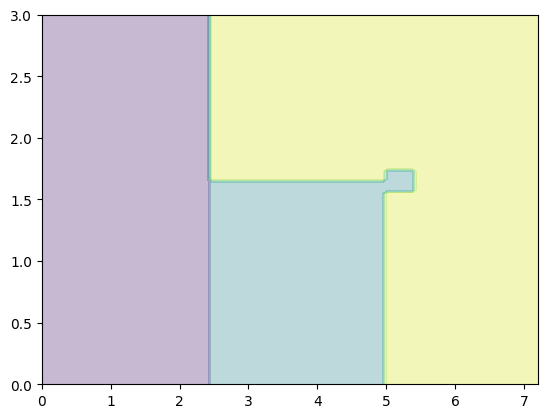

In [48]:
#전체영역에 대한 예측
import numpy as np
lengths, widths = np.meshgrid(np.linspace(0, 7.2, 100), np.linspace(0,3,100))
# lengths
x_iris_all = np.c_[lengths.ravel(), widths.ravel()]   #차원을 펴는것..?
# x_iris_all
y_pred=tree.predict(x_iris_all).reshape(lengths.shape)
plt.contourf(lengths, widths,y_pred,alpha=0.3);





In [49]:
widths.shape, lengths.shape

((100, 100), (100, 100))

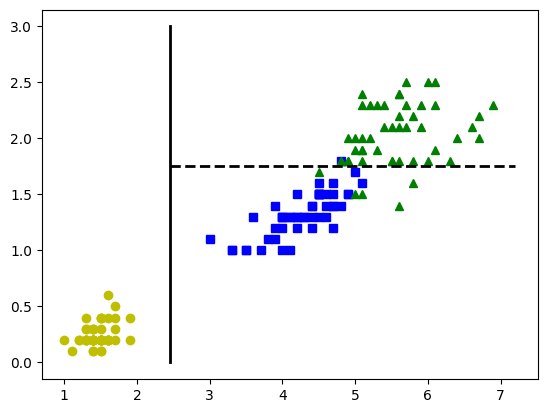

In [ ]:
# 실제 데이터 포인트 그리기
for idx, (name, style) in enumerate(zip(iris.target_names, ("yo", "bs", "g^"))):
    plt.plot(X.to_numpy()[:, 0][y == idx], X.to_numpy()[:, 1][y == idx],
             style, label=f"Iris {name}")

# 더 깊은 트리를 학습시켜 실제 결정선(분기 조건) 가져오기
# max_depth ( 나무의 깊이를 제한 (질문 몇 번까지만 하자!)) 가 높을 수록 과대적합하게됨..
tree_clf_deeper = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf_deeper.fit(X, y)
th0, th1, th2a, th2b = tree_clf_deeper.tree_.threshold[[0, 2, 3, 6]]

# 결정선 그리기
plt.plot([th0, th0], [0, 3], "k-", linewidth=2) # 첫 번째 분기 (실선)
plt.plot([th0, 7.2], [th1, th1], "k--", linewidth=2) # 두 번째 분기 (파선)


In [55]:
# tree (결정트리) : 지니계수 지니불순도. 자식노드가 순수상태가 되는 방향으로 계속 트리를 확장
# 스케일링 필요없고
# 중요 피처에 대한 정보를 알려줌
# 과적합(overfitting)이 일어나기 쉬운 구조

In [115]:
# 성능 측정을 위한 데이터 분할
from sklearn.datasets import load_iris
iris = load_iris()
X=iris.data
y=iris.target

#데이터분할
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, stratify=y, test_size=0.2, random_state=42)

#학습
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(max_depth=3)
tree.fit(X_train, y_train)

#예측
y_hat = tree.predict(X_test)

#리포트
from sklearn.metrics import classification_report
print(classification_report(y_test, y_hat))

#중요 feature 출력
tree.feature_importances_, iris.feature_names

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



(array([0.        , 0.        , 0.57907728, 0.42092272]),
 ['sepal length (cm)',
  'sepal width (cm)',
  'petal length (cm)',
  'petal width (cm)'])

In [119]:
#하이퍼 파라미터 튜닝
from sklearn.model_selection import GridSearchCV
tree = DecisionTreeClassifier()
param_grid = {
    'criterion' : ['gini', 'entropy', 'log_loss'],
    'max_depth' : range(1,10)   
}
grid_searchcv = GridSearchCV(tree, param_grid=param_grid, cv=3, verbose=1, n_jobs=-1)
grid_searchcv.fit(X_train,y_train)

Fitting 3 folds for each of 27 candidates, totalling 81 fits


,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy', ...], 'max_depth': range(1, 10)}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [121]:
print(grid_searchcv.best_params_)
print(grid_searchcv.best_score_)
grid_searchcv.best_estimator_

{'criterion': 'gini', 'max_depth': 3}
0.9583333333333334


,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None
